In [3]:
#-------Set up environment--------
options(warn = -1, verbose=FALSE)
library(dplyr)
library(Seurat)
library(httr)
library(readr)
library(harmony)
library(MAST)
library(unixtools)
library(ggplot2)
library(cowplot)
library(future)
library(repr)
library(ggmin)
library(pheatmap)
set_config(config(ssl_verifypeer = 0L))
ulimit::memory_limit(250000)
setwd("/data/lucy/MacroFibroAtlas/2026")
set.tempdir("/data/lucy/tmp/")

soft   hard 
250000    Inf

In [5]:
mfatlas <- readRDS("mfatlas.rds")

In [109]:
macro.cols <- c("#71E9FC","#3A83EE","#6D3AE9","magenta3","#892450","red","#FFA100","#FFF301","#98FF00","#00EE11","#00A585")
fibro.cols <- c("#5DA5DAFF", "#FAA43AFF", "#60BD68FF", "#F17CB0FF", "#B2912FFF", "#B276B2FF", "#DECF3FFF", "#F15854FF")
cluster.cols <- c(macro.cols, fibro.cols)

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



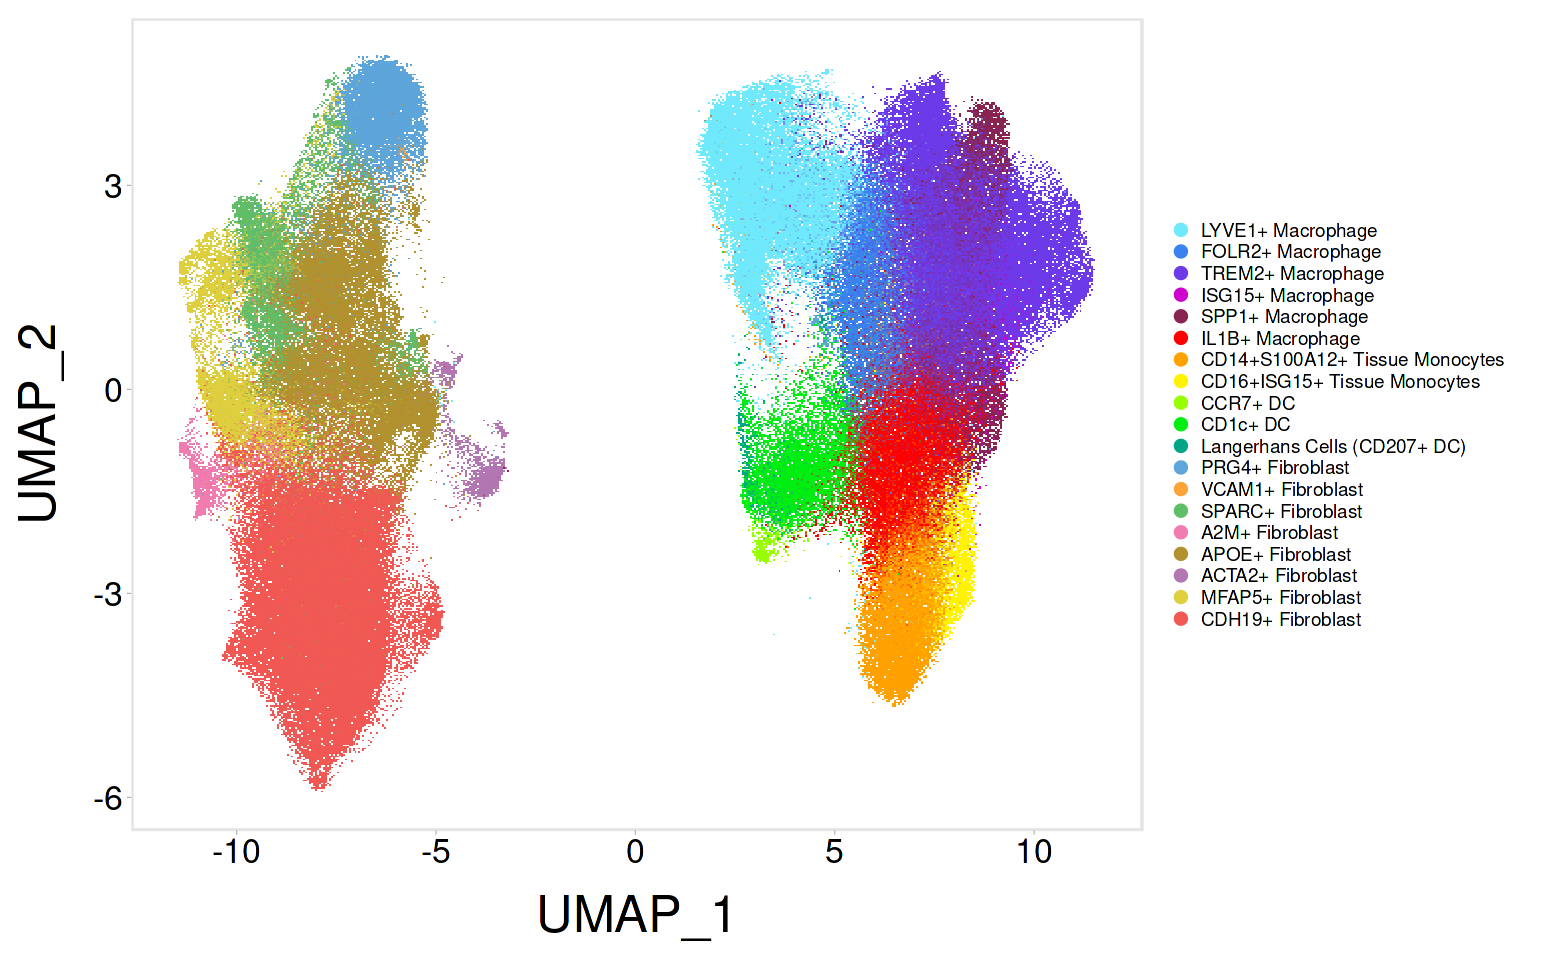

In [110]:
Idents(mfatlas) <- "finalclusters"
options(repr.plot.width=13, repr.plot.height=8)
DimPlot(object = mfatlas, reduction = "umap", cols=cluster.cols) + theme_powerpoint() + theme(axis.text=element_text(size=20),axis.title=element_text(size=30))

# Isolate macrophage

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



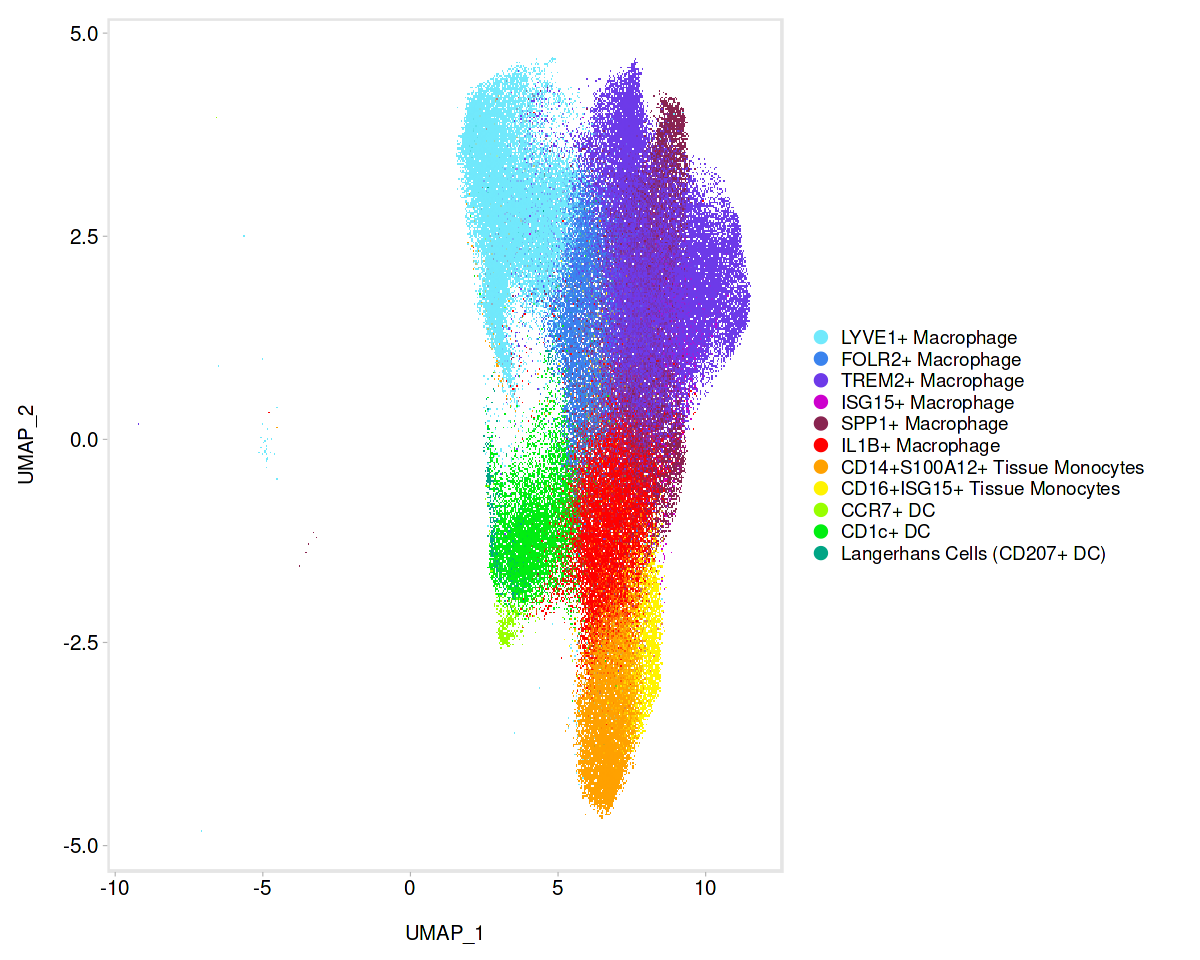

In [111]:
harmony.macro <- subset(mfatlas, idents=c("LYVE1+ Macrophage","FOLR2+ Macrophage","TREM2+ Macrophage","SPP1+ Macrophage",
                                                          "IL1B+ Macrophage","ISG15+ Macrophage",
                                                         "CD14+S100A12+ Tissue Monocytes","CD16+ISG15+ Tissue Monocytes","CCR7+ DC",
                                                         "Langerhans Cells (CD207+ DC)","CD1c+ DC"))
options(repr.plot.width=10, repr.plot.height=8)
names(macro.cols) <- levels(Idents(harmony.macro))
DimPlot(object = harmony.macro, reduction = "umap", cols=macro.cols, pt.size=1) + theme_powerpoint()

In [131]:
tissue.cols <- c("Synovium"="#BC80F8", 
                 "Skin"="#00C0C4", 
                 "Lung"="#87AD34", 
                 "Heart"="#E77D72")

# IL1B+ Macrophage

In [112]:
il1bpos <- subset(harmony.macro, idents="IL1B+ Macrophage")

In [115]:
#Set identity of cells to tissue of origin
Idents(il1bpos) <- "tissue"

In [116]:
table(il1bpos$tissue)


   Heart     Lung     Skin Synovium 
    1365     7426     1329     6563 

In [232]:
# Identify marker genes of that cluster to plot across tissues

In [117]:
cluster.markers <- read.csv("/data/lucy/MacroFibroAtlas/TotalMFTIntegration/harmony.macro-renamed-MAST-30dims-res1.2-minpct0.4.csv")

In [118]:
il1bpos.Markers <- cluster.markers[cluster.markers$cluster=="IL1B+ Macrophage",]

In [119]:
top50 <- il1bpos.Markers %>%  top_n(n = 50, wt = avg_logFC)

In [120]:
il1bpos.avg <- AverageExpression(il1bpos, return.seurat=TRUE, add.ident="tissue_state")

Centering and scaling data matrix



In [121]:
unique(colnames(il1bpos.avg))

[1] "Lung_Lung-Homeostasis"         "Lung_Lung-Disease"            
[3] "Skin_Skin-Homeostasis"         "Skin_Skin-Disease"            
[5] "Synovium_Synovium-Homeostasis" "Synovium_Synovium-Disease"    
[7] "Heart_Heart-Homeostasis"       "Heart_Heart-Disease"

In [122]:
il1bpos.avg$tissue <- sub("\\_.*", "", colnames(il1bpos.avg))
unique(il1bpos.avg$tissue)

[1] "Lung"     "Skin"     "Synovium" "Heart"

In [123]:
levels(il1bpos.avg@meta.data$tissue)

NULL

In [124]:
il1bpos.avg$state <- sub(".*-", "", colnames(il1bpos.avg))
unique(il1bpos.avg$state)

[1] "Homeostasis" "Disease"

In [125]:
head(il1bpos.avg@meta.data)

,orig.ident,tissue_state,tissue,state
,<chr>,<chr>,<chr>,<chr>
Lung_Lung-Homeostasis,Lung,Lung-Homeostasis,Lung,Homeostasis
Lung_Lung-Disease,Lung,Lung-Disease,Lung,Disease
Skin_Skin-Homeostasis,Skin,Skin-Homeostasis,Skin,Homeostasis
Skin_Skin-Disease,Skin,Skin-Disease,Skin,Disease
Synovium_Synovium-Homeostasis,Synovium,Synovium-Homeostasis,Synovium,Homeostasis
Synovium_Synovium-Disease,Synovium,Synovium-Disease,Synovium,Disease


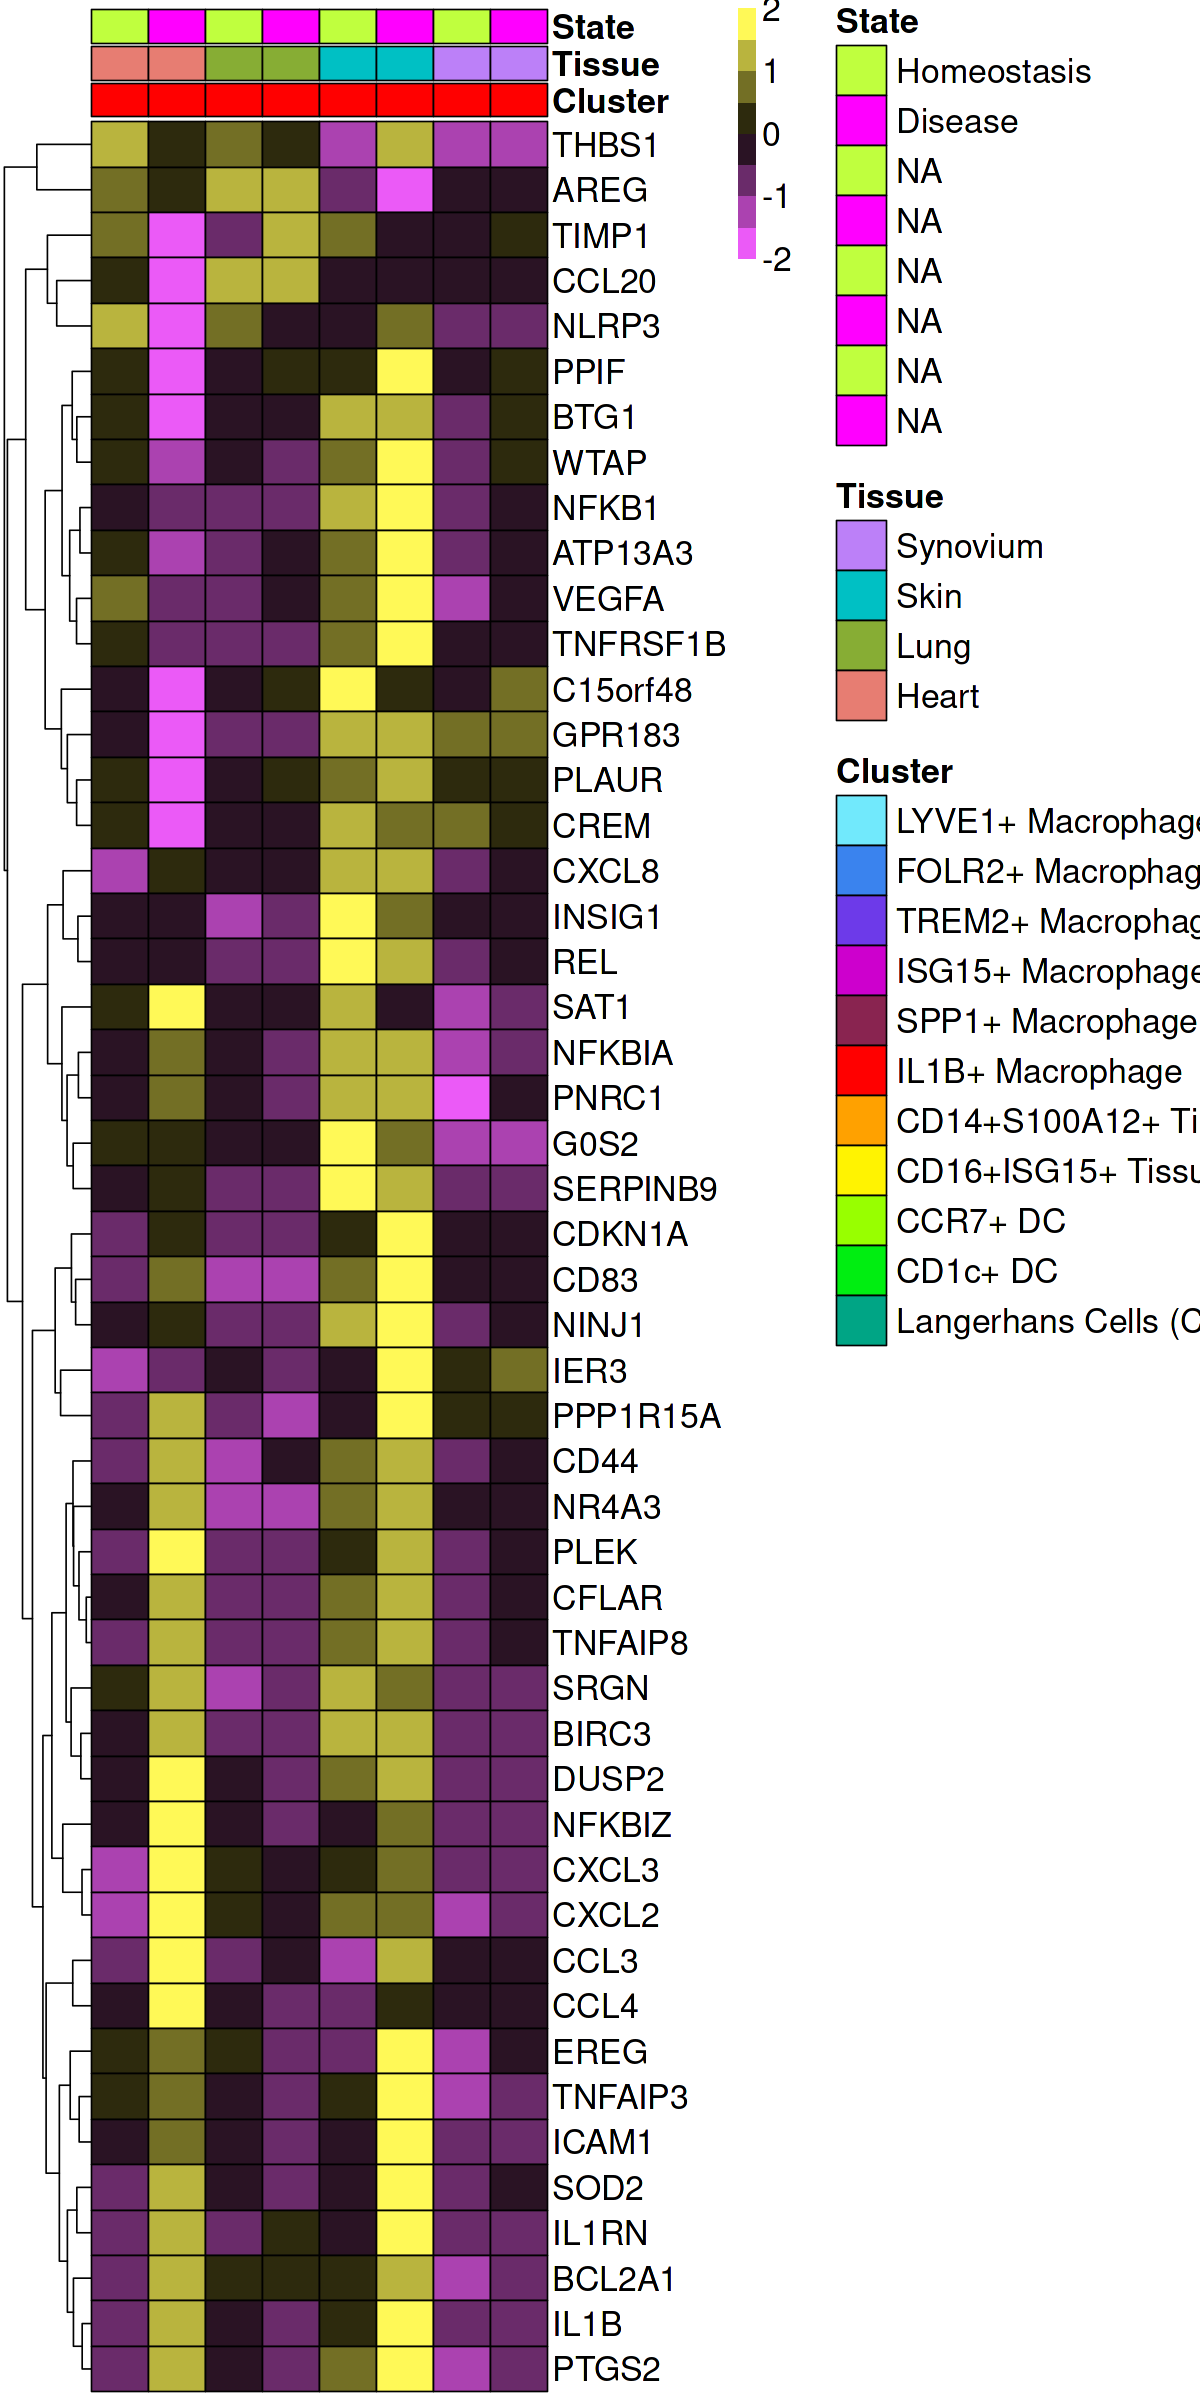

In [133]:
#Make your own
matrix <- GetAssayData(il1bpos.avg, slot="data")
subset.matrix <- matrix[c(top50$gene), ]
data <- as.matrix(subset.matrix)
#Reposition the breaks at the quantiles of the data, then each color will represent an equal proportion of the data:
mat_breaks <- seq(min(data), max(data), length.out = 10)
quantile_breaks <- function(xs, n = 10) {
  breaks <- quantile(xs, probs = seq(0, 1, length.out = n))
  breaks[!duplicated(breaks)]
}
mat_breaks <- quantile_breaks(data, n = 11)

#Add metadata
il1bpos.avg@meta.data$cluster <- "IL1B+ Macrophage"
annotation_col <- as.data.frame(il1bpos.avg@meta.data %>% select(cluster, tissue, state))

colnames(annotation_col) <- c("Cluster","Tissue","State")

#Create colour scheme
state.cols <- rep(c("olivedrab1","magenta1"),4)
names(state.cols) <- unique(il1bpos.avg@meta.data$state)
metacols <- list(
  Cluster = macro.cols,
  Tissue = tissue.cols,
  State = state.cols)

#Order cells by cluster
data <- data[,order(annotation_col$Tissue)]
#Scale data
scale_rows <- function(x) t(scale(t(x)))
data <- scale_rows(data) # Z-score
data[data > 2] <- 2
data[data < -2] <- -2

options(repr.plot.width=10, repr.plot.height=20)
#Generate heatmap
pheatmap(
  mat = data,
  border_color = "black",
  color = colorRampPalette(c("#EB5AF7","#0B0801","#FFF957"))(8),
  show_rownames = TRUE,
  show_colnames = FALSE,
  cluster_rows = TRUE,
  cluster_cols = FALSE,
  annotation_col = annotation_col,
  annotation_colors = metacols,
  fontsize = 20,
  fontsize_row = 20,
  scale = "none")

# SPP1+ Macrophage

In [78]:
spp1pos <- subset(harmony.macro, idents="SPP1+ Macrophage")

In [81]:
#Set identity of cells to tissue of origin
Idents(spp1pos) <- "tissue"

In [82]:
table(spp1pos$tissue)


   Heart     Lung     Skin Synovium 
     739     7320      201     2449 

In [ ]:
# Identify marker genes of that cluster to plot across tissues

In [83]:
cluster.markers <- read.csv("/data/lucy/MacroFibroAtlas/TotalMFTIntegration/harmony.macro-renamed-MAST-30dims-res1.2-minpct0.4.csv")

In [136]:
spp1pos.Markers <- cluster.markers[cluster.markers$cluster=="SPP1+ Macrophage",]

In [137]:
top50 <- spp1pos.Markers %>%  top_n(n = 50, wt = avg_logFC)

In [138]:
spp1pos.avg <- AverageExpression(spp1pos, return.seurat=TRUE, add.ident="tissue_state")

Centering and scaling data matrix



In [139]:
unique(colnames(spp1pos.avg))

[1] "Lung_Lung-Homeostasis"         "Lung_Lung-Disease"            
[3] "Skin_Skin-Homeostasis"         "Skin_Skin-Disease"            
[5] "Synovium_Synovium-Homeostasis" "Synovium_Synovium-Disease"    
[7] "Heart_Heart-Homeostasis"       "Heart_Heart-Disease"

In [140]:
spp1pos.avg$tissue <- sub("\\_.*", "", colnames(spp1pos.avg))
unique(spp1pos.avg$tissue)

[1] "Lung"     "Skin"     "Synovium" "Heart"

In [141]:
levels(spp1pos.avg@meta.data$tissue)

NULL

In [142]:
spp1pos.avg$state <- sub(".*-", "", colnames(spp1pos.avg))
unique(spp1pos.avg$state)

[1] "Homeostasis" "Disease"

In [143]:
head(spp1pos.avg@meta.data)

,orig.ident,tissue_state,tissue,state
,<chr>,<chr>,<chr>,<chr>
Lung_Lung-Homeostasis,Lung,Lung-Homeostasis,Lung,Homeostasis
Lung_Lung-Disease,Lung,Lung-Disease,Lung,Disease
Skin_Skin-Homeostasis,Skin,Skin-Homeostasis,Skin,Homeostasis
Skin_Skin-Disease,Skin,Skin-Disease,Skin,Disease
Synovium_Synovium-Homeostasis,Synovium,Synovium-Homeostasis,Synovium,Homeostasis
Synovium_Synovium-Disease,Synovium,Synovium-Disease,Synovium,Disease


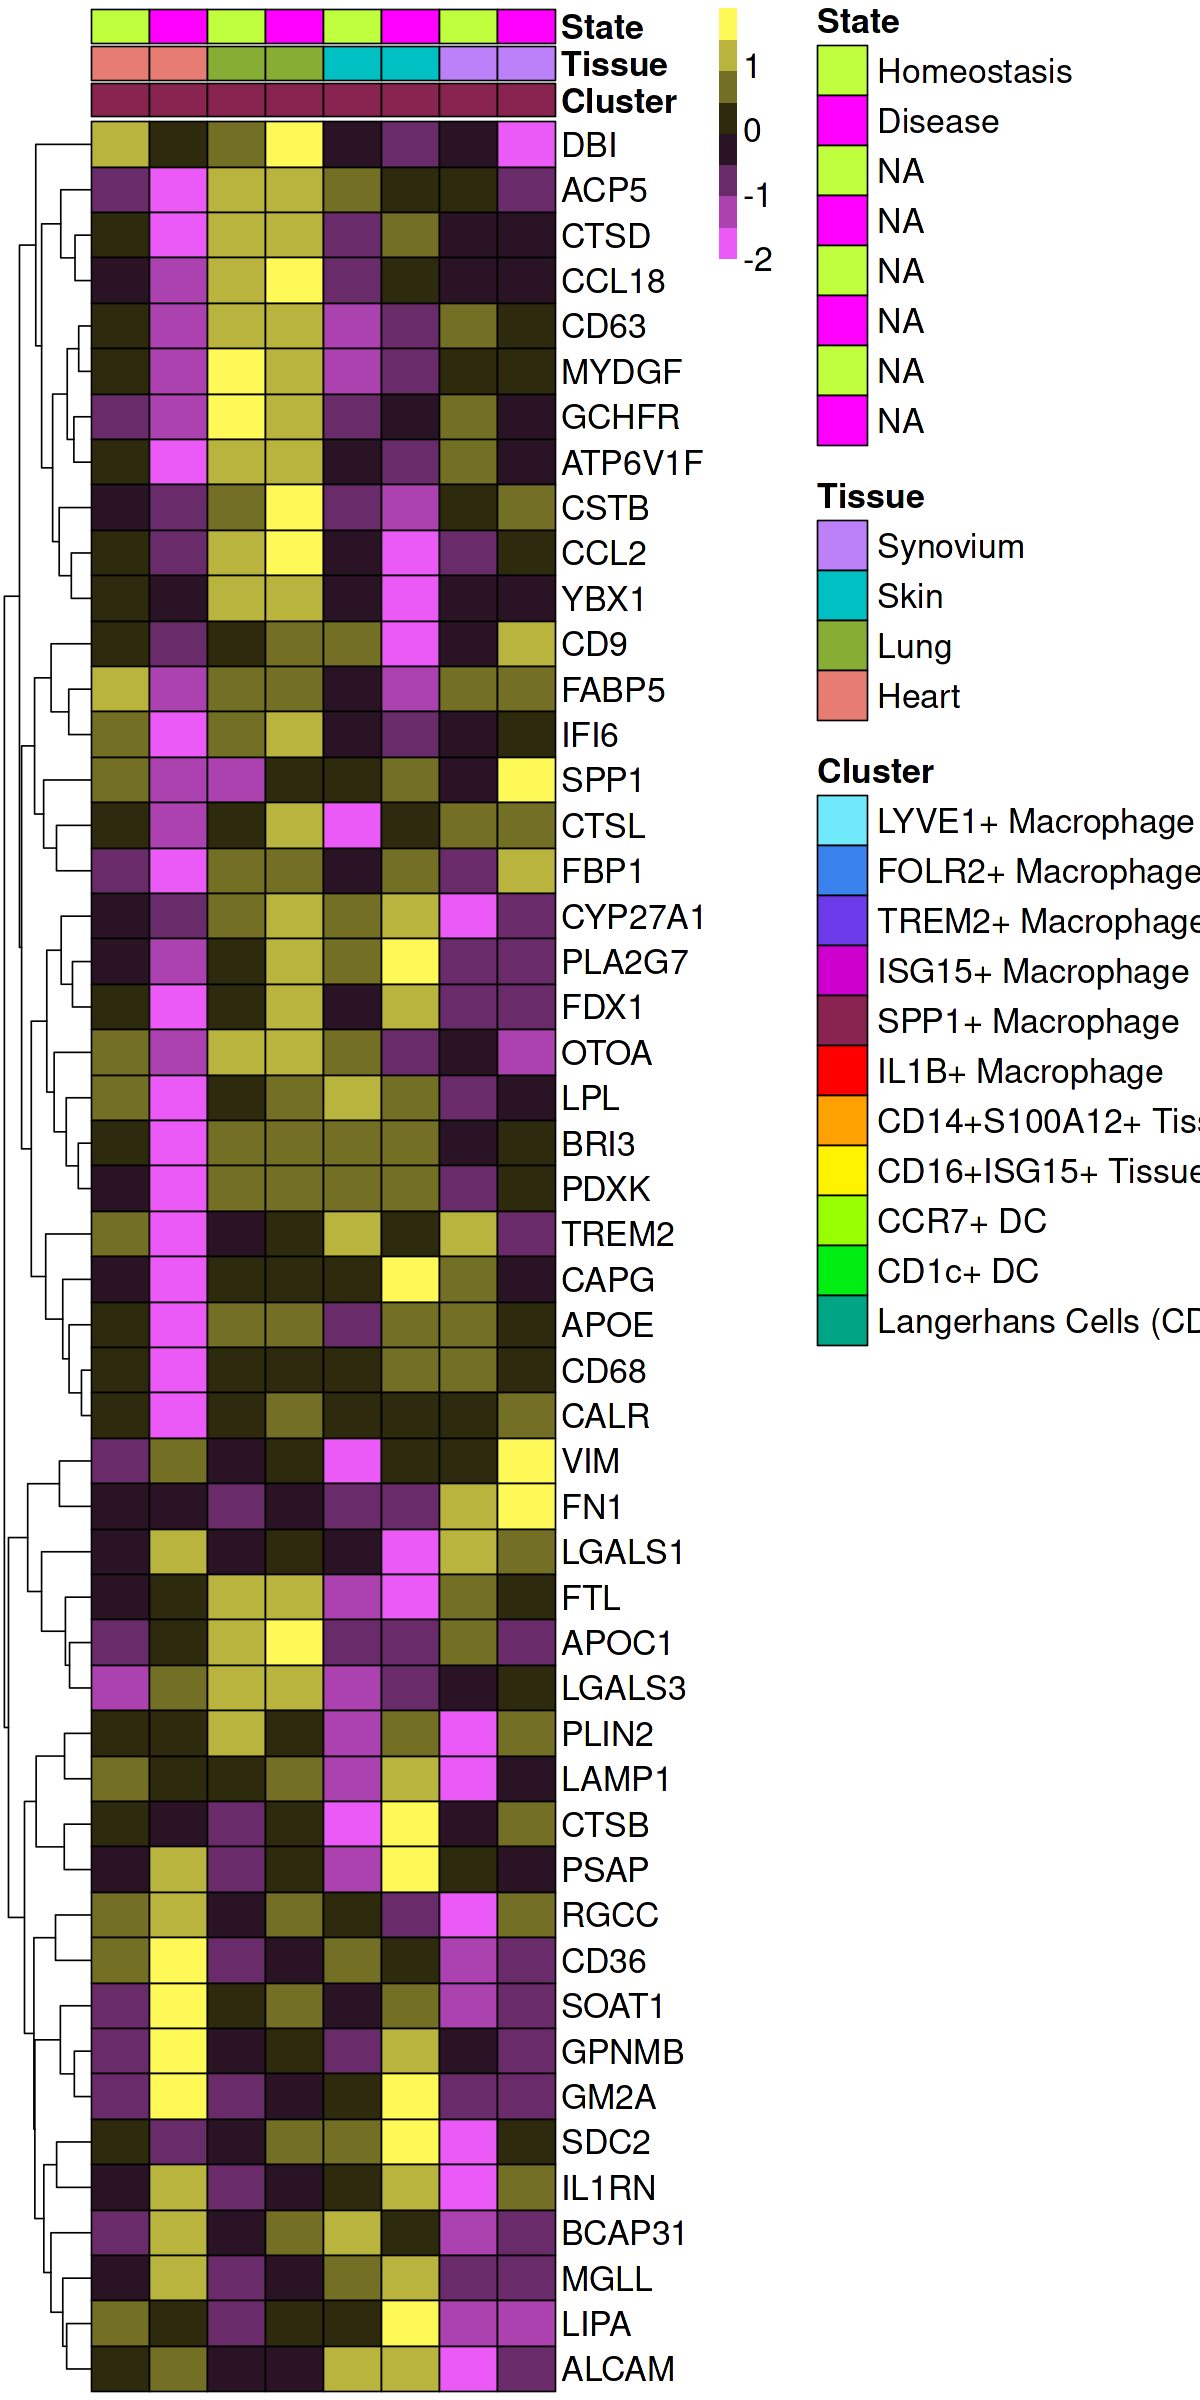

In [144]:
#Make your own
matrix <- GetAssayData(spp1pos.avg, slot="data")
subset.matrix <- matrix[c(top50$gene), ]
data <- as.matrix(subset.matrix)
#Reposition the breaks at the quantiles of the data, then each color will represent an equal proportion of the data:
mat_breaks <- seq(min(data), max(data), length.out = 10)
quantile_breaks <- function(xs, n = 10) {
  breaks <- quantile(xs, probs = seq(0, 1, length.out = n))
  breaks[!duplicated(breaks)]
}
mat_breaks <- quantile_breaks(data, n = 11)

#Add metadata
spp1pos.avg@meta.data$cluster <- "SPP1+ Macrophage"
annotation_col <- as.data.frame(spp1pos.avg@meta.data %>% select(cluster, tissue, state))

colnames(annotation_col) <- c("Cluster","Tissue","State")

#Create colour scheme
state.cols <- rep(c("olivedrab1","magenta1"),4)
names(state.cols) <- unique(spp1pos.avg@meta.data$state)
metacols <- list(
  Cluster = macro.cols,
  Tissue = tissue.cols,
  State = state.cols)

#Order cells by cluster
data <- data[,order(annotation_col$Tissue)]
#Scale data
scale_rows <- function(x) t(scale(t(x)))
data <- scale_rows(data) # Z-score
data[data > 2] <- 2
data[data < -2] <- -2

options(repr.plot.width=10, repr.plot.height=20)
#Generate heatmap
pheatmap(
  mat = data,
  border_color = "black",
  color = colorRampPalette(c("#EB5AF7","#0B0801","#FFF957"))(8),
  show_rownames = TRUE,
  show_colnames = FALSE,
  cluster_rows = TRUE,
  cluster_cols = FALSE,
  annotation_col = annotation_col,
  annotation_colors = metacols,
  fontsize = 20,
  fontsize_row = 20,
  scale = "none")

# Isolate fibroblasts

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



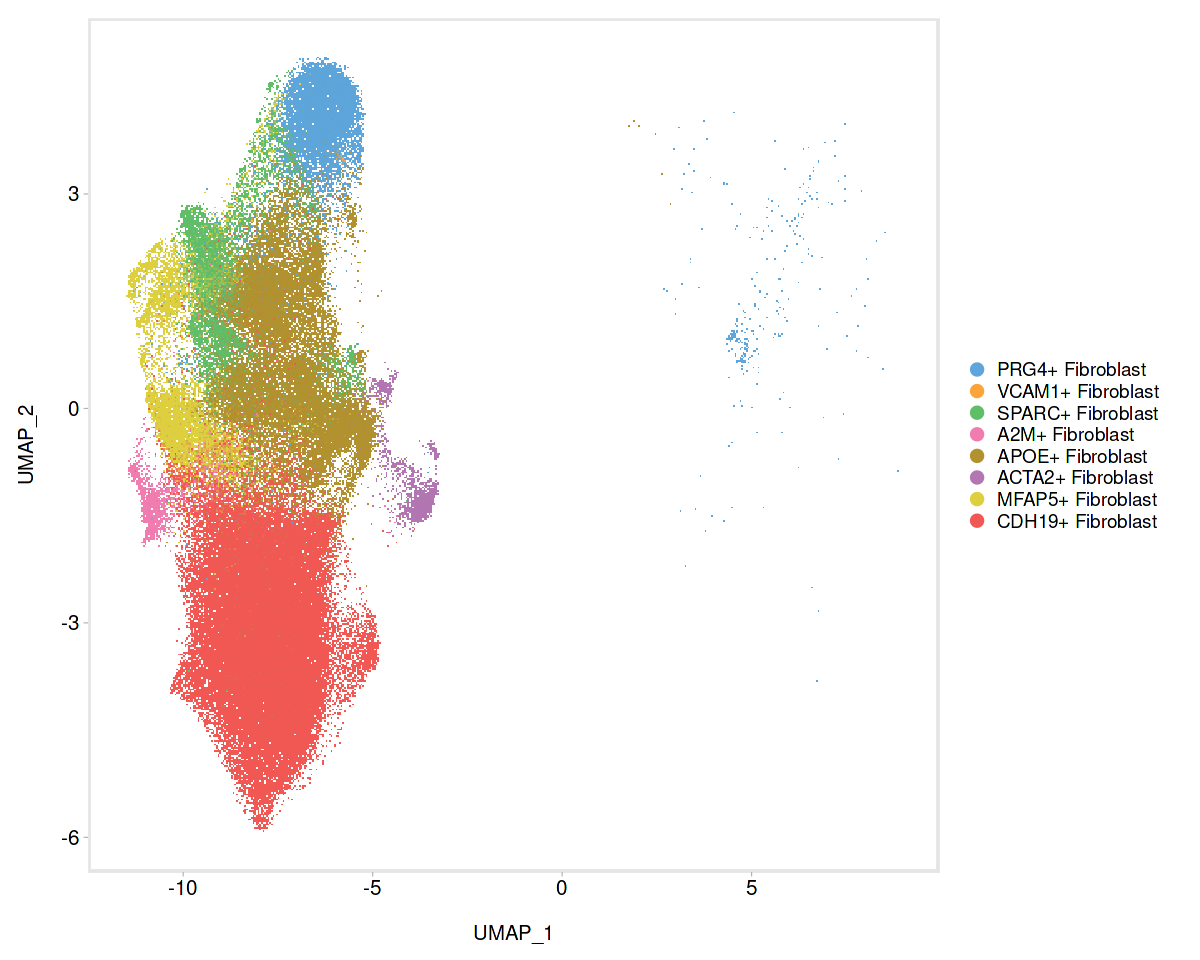

In [161]:
harmony.fibro <- subset(mfatlas, idents=c("PRG4+ Fibroblast","VCAM1+ Fibroblast","SPARC+ Fibroblast",
                                "A2M+ Fibroblast","APOE+ Fibroblast","ACTA2+ Fibroblast","MFAP5+ Fibroblast","CDH19+ Fibroblast"))
options(repr.plot.width=10, repr.plot.height=8)
fibro.cols <- c("#5DA5DAFF", "#FAA43AFF", "#60BD68FF", "#F17CB0FF", "#B2912FFF", "#B276B2FF", "#DECF3FFF", "#F15854FF")
names(fibro.cols) <- levels(Idents(harmony.fibro))
DimPlot(object = harmony.fibro, reduction = "umap", cols=fibro.cols, pt.size=1) + theme_powerpoint()

# APOE+ Fibroblast

In [146]:
apoepos <- subset(harmony.fibro, idents="APOE+ Fibroblast")

In [149]:
#Set identity of cells to tissue of origin
Idents(apoepos) <- "tissue"

In [150]:
table(apoepos$tissue)


   Heart     Lung     Skin Synovium 
    1334      475    11703    12141 

In [233]:
# Identify marker genes of that cluster to plot across tissues

In [151]:
cluster.markers <- read.csv("/data/lucy/MacroFibroAtlas/TotalMFTIntegration/harmony.fibro-renamed-MAST-30dims-res1.2-minpct0.4.csv")

In [152]:
apoepos.Markers <- cluster.markers[cluster.markers$cluster=="APOE+ Fibroblast",]

In [167]:
#Ignore genes encoding ribosomal proteins
# Assuming your gene names are in a column named 'gene_name'
apoepos.Markers <- apoepos.Markers %>%
  filter(!str_starts(gene, "RPS") & !str_starts(gene, "RPL"))


In [169]:
top50 <- apoepos.Markers %>%  top_n(n = 50, wt = avg_logFC)

In [170]:
postnpos.avg <- AverageExpression(postnpos, return.seurat=TRUE, add.ident="tissue_state")

Centering and scaling data matrix



In [171]:
unique(colnames(postnpos.avg))

[1] "Lung_Lung-Homeostasis"         "Lung_Lung-Disease"            
[3] "Skin_Skin-Homeostasis"         "Skin_Skin-Disease"            
[5] "Synovium_Synovium-Homeostasis" "Synovium_Synovium-Disease"    
[7] "Heart_Heart-Homeostasis"       "Heart_Heart-Disease"

In [172]:
postnpos.avg$tissue <- sub("\\_.*", "", colnames(postnpos.avg))
unique(postnpos.avg$tissue)

[1] "Lung"     "Skin"     "Synovium" "Heart"

In [173]:
levels(postnpos.avg@meta.data$tissue)

NULL

In [174]:
postnpos.avg$state <- sub(".*-", "", colnames(postnpos.avg))
unique(postnpos.avg$state)

[1] "Homeostasis" "Disease"

In [175]:
head(postnpos.avg@meta.data)

,orig.ident,tissue_state,tissue,state
,<chr>,<chr>,<chr>,<chr>
Lung_Lung-Homeostasis,Lung,Lung-Homeostasis,Lung,Homeostasis
Lung_Lung-Disease,Lung,Lung-Disease,Lung,Disease
Skin_Skin-Homeostasis,Skin,Skin-Homeostasis,Skin,Homeostasis
Skin_Skin-Disease,Skin,Skin-Disease,Skin,Disease
Synovium_Synovium-Homeostasis,Synovium,Synovium-Homeostasis,Synovium,Homeostasis
Synovium_Synovium-Disease,Synovium,Synovium-Disease,Synovium,Disease


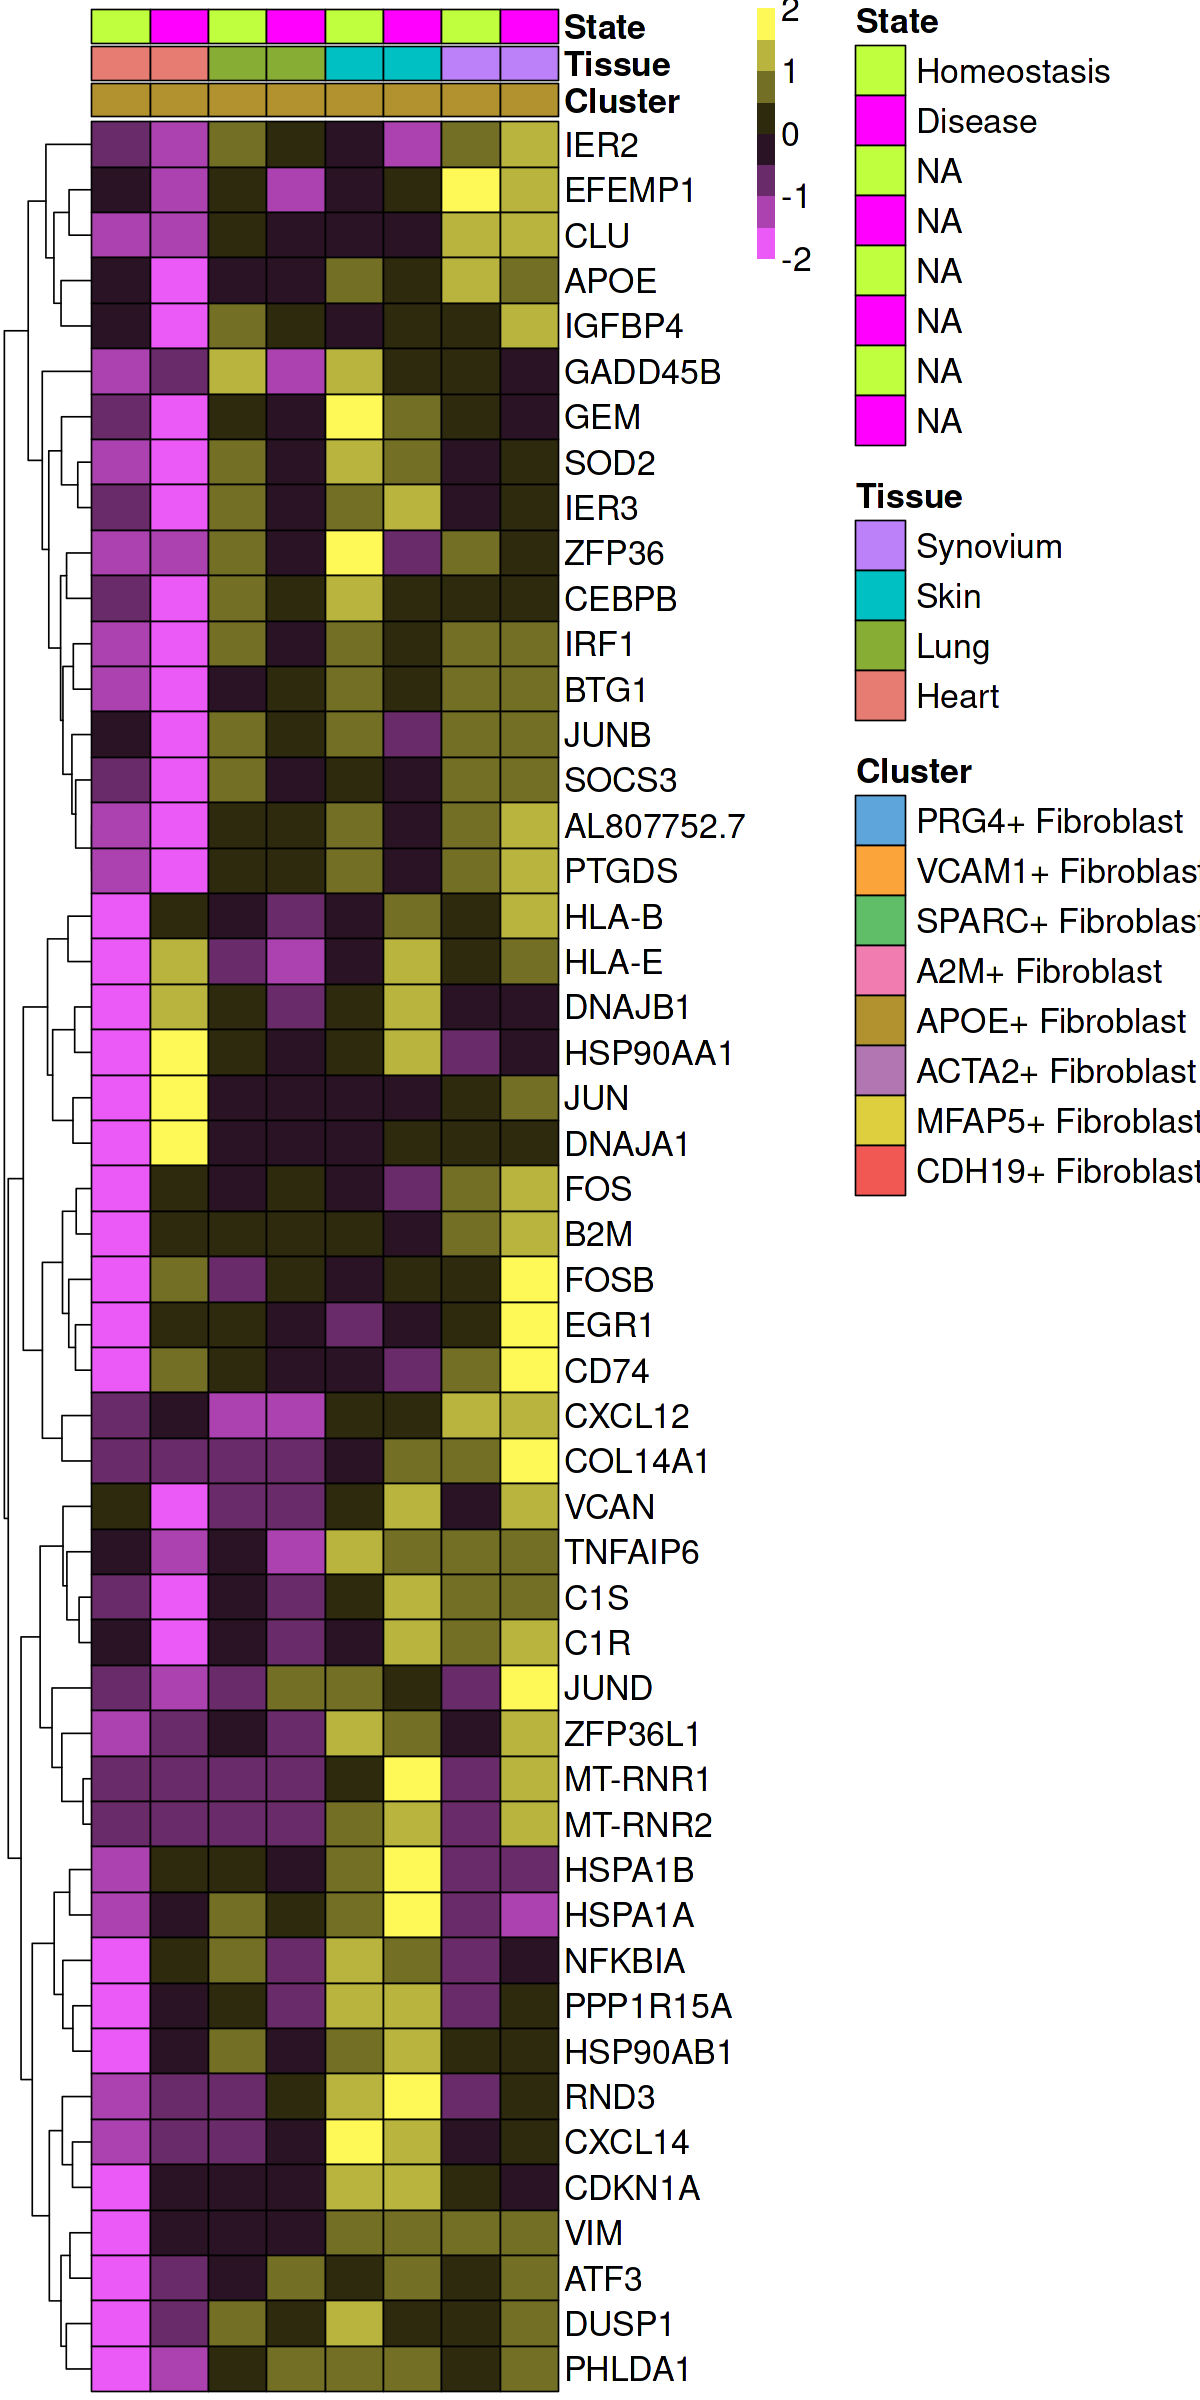

In [176]:
#Make your own
matrix <- GetAssayData(postnpos.avg, slot="data")
subset.matrix <- matrix[c(top50$gene), ]
data <- as.matrix(subset.matrix)
#Reposition the breaks at the quantiles of the data, then each color will represent an equal proportion of the data:
mat_breaks <- seq(min(data), max(data), length.out = 10)
quantile_breaks <- function(xs, n = 10) {
  breaks <- quantile(xs, probs = seq(0, 1, length.out = n))
  breaks[!duplicated(breaks)]
}
mat_breaks <- quantile_breaks(data, n = 11)

#Add metadata
postnpos.avg@meta.data$cluster <- "APOE+ Fibroblast"
annotation_col <- as.data.frame(postnpos.avg@meta.data %>% select(cluster, tissue, state))

colnames(annotation_col) <- c("Cluster","Tissue","State")

#Create colour scheme
state.cols <- rep(c("olivedrab1","magenta1"),4)
names(state.cols) <- unique(postnpos.avg@meta.data$state)
metacols <- list(
  Cluster = fibro.cols,
  Tissue = tissue.cols,
  State = state.cols)

#Order cells by cluster
data <- data[,order(annotation_col$Tissue)]
#Scale data
scale_rows <- function(x) t(scale(t(x)))
data <- scale_rows(data) # Z-score
data[data > 2] <- 2
data[data < -2] <- -2

options(repr.plot.width=10, repr.plot.height=20)
#Generate heatmap
pheatmap(
  mat = data,
  border_color = "black",
  color = colorRampPalette(c("#EB5AF7","#0B0801","#FFF957"))(8),
  show_rownames = TRUE,
  show_colnames = FALSE,
  cluster_rows = TRUE,
  cluster_cols = FALSE,
  annotation_col = annotation_col,
  annotation_colors = metacols,
  fontsize = 20,
  fontsize_row = 20,
  scale = "none")

# POSTN(SPARC)+ Fibroblast

In [181]:
postnpos <- subset(harmony.fibro, idents="SPARC+ Fibroblast")

In [184]:
#Set identity of cells to tissue of origin
Idents(postnpos) <- "tissue"

In [185]:
table(postnpos$tissue)


   Heart     Lung     Skin Synovium 
     152      149     2971     4963 

In [204]:
cluster.markers <- read.csv("/data/lucy/MacroFibroAtlas/TotalMFTIntegration/harmony.fibro-renamed-MAST-30dims-res1.2-minpct0.4.csv")

In [209]:
postnpos.Markers <- cluster.markers[cluster.markers$cluster=="SPARC+POSTN+ Fibroblast",]

In [211]:
library(stringr)
# Assuming your gene names are in a column named 'gene_name'
postnpos.Markers <- postnpos.Markers %>%
  filter(!str_starts(gene, "RPS") & !str_starts(gene, "RPL"))


In [212]:
top50 <- postnpos.Markers %>%  top_n(n = 50, wt = avg_logFC)

In [213]:
postnpos.avg <- AverageExpression(postnpos, return.seurat=TRUE, add.ident="tissue_state")

Centering and scaling data matrix



In [214]:
unique(colnames(postnpos.avg))

[1] "Lung_Lung-Homeostasis"         "Lung_Lung-Disease"            
[3] "Skin_Skin-Homeostasis"         "Skin_Skin-Disease"            
[5] "Synovium_Synovium-Homeostasis" "Synovium_Synovium-Disease"    
[7] "Heart_Heart-Homeostasis"       "Heart_Heart-Disease"

In [215]:
postnpos.avg$tissue <- sub("\\_.*", "", colnames(postnpos.avg))
unique(postnpos.avg$tissue)

[1] "Lung"     "Skin"     "Synovium" "Heart"

In [216]:
levels(postnpos.avg@meta.data$tissue)

NULL

In [217]:
postnpos.avg$state <- sub(".*-", "", colnames(postnpos.avg))
unique(postnpos.avg$state)

[1] "Homeostasis" "Disease"

In [218]:
head(postnpos.avg@meta.data)

,orig.ident,tissue_state,tissue,state
,<chr>,<chr>,<chr>,<chr>
Lung_Lung-Homeostasis,Lung,Lung-Homeostasis,Lung,Homeostasis
Lung_Lung-Disease,Lung,Lung-Disease,Lung,Disease
Skin_Skin-Homeostasis,Skin,Skin-Homeostasis,Skin,Homeostasis
Skin_Skin-Disease,Skin,Skin-Disease,Skin,Disease
Synovium_Synovium-Homeostasis,Synovium,Synovium-Homeostasis,Synovium,Homeostasis
Synovium_Synovium-Disease,Synovium,Synovium-Disease,Synovium,Disease


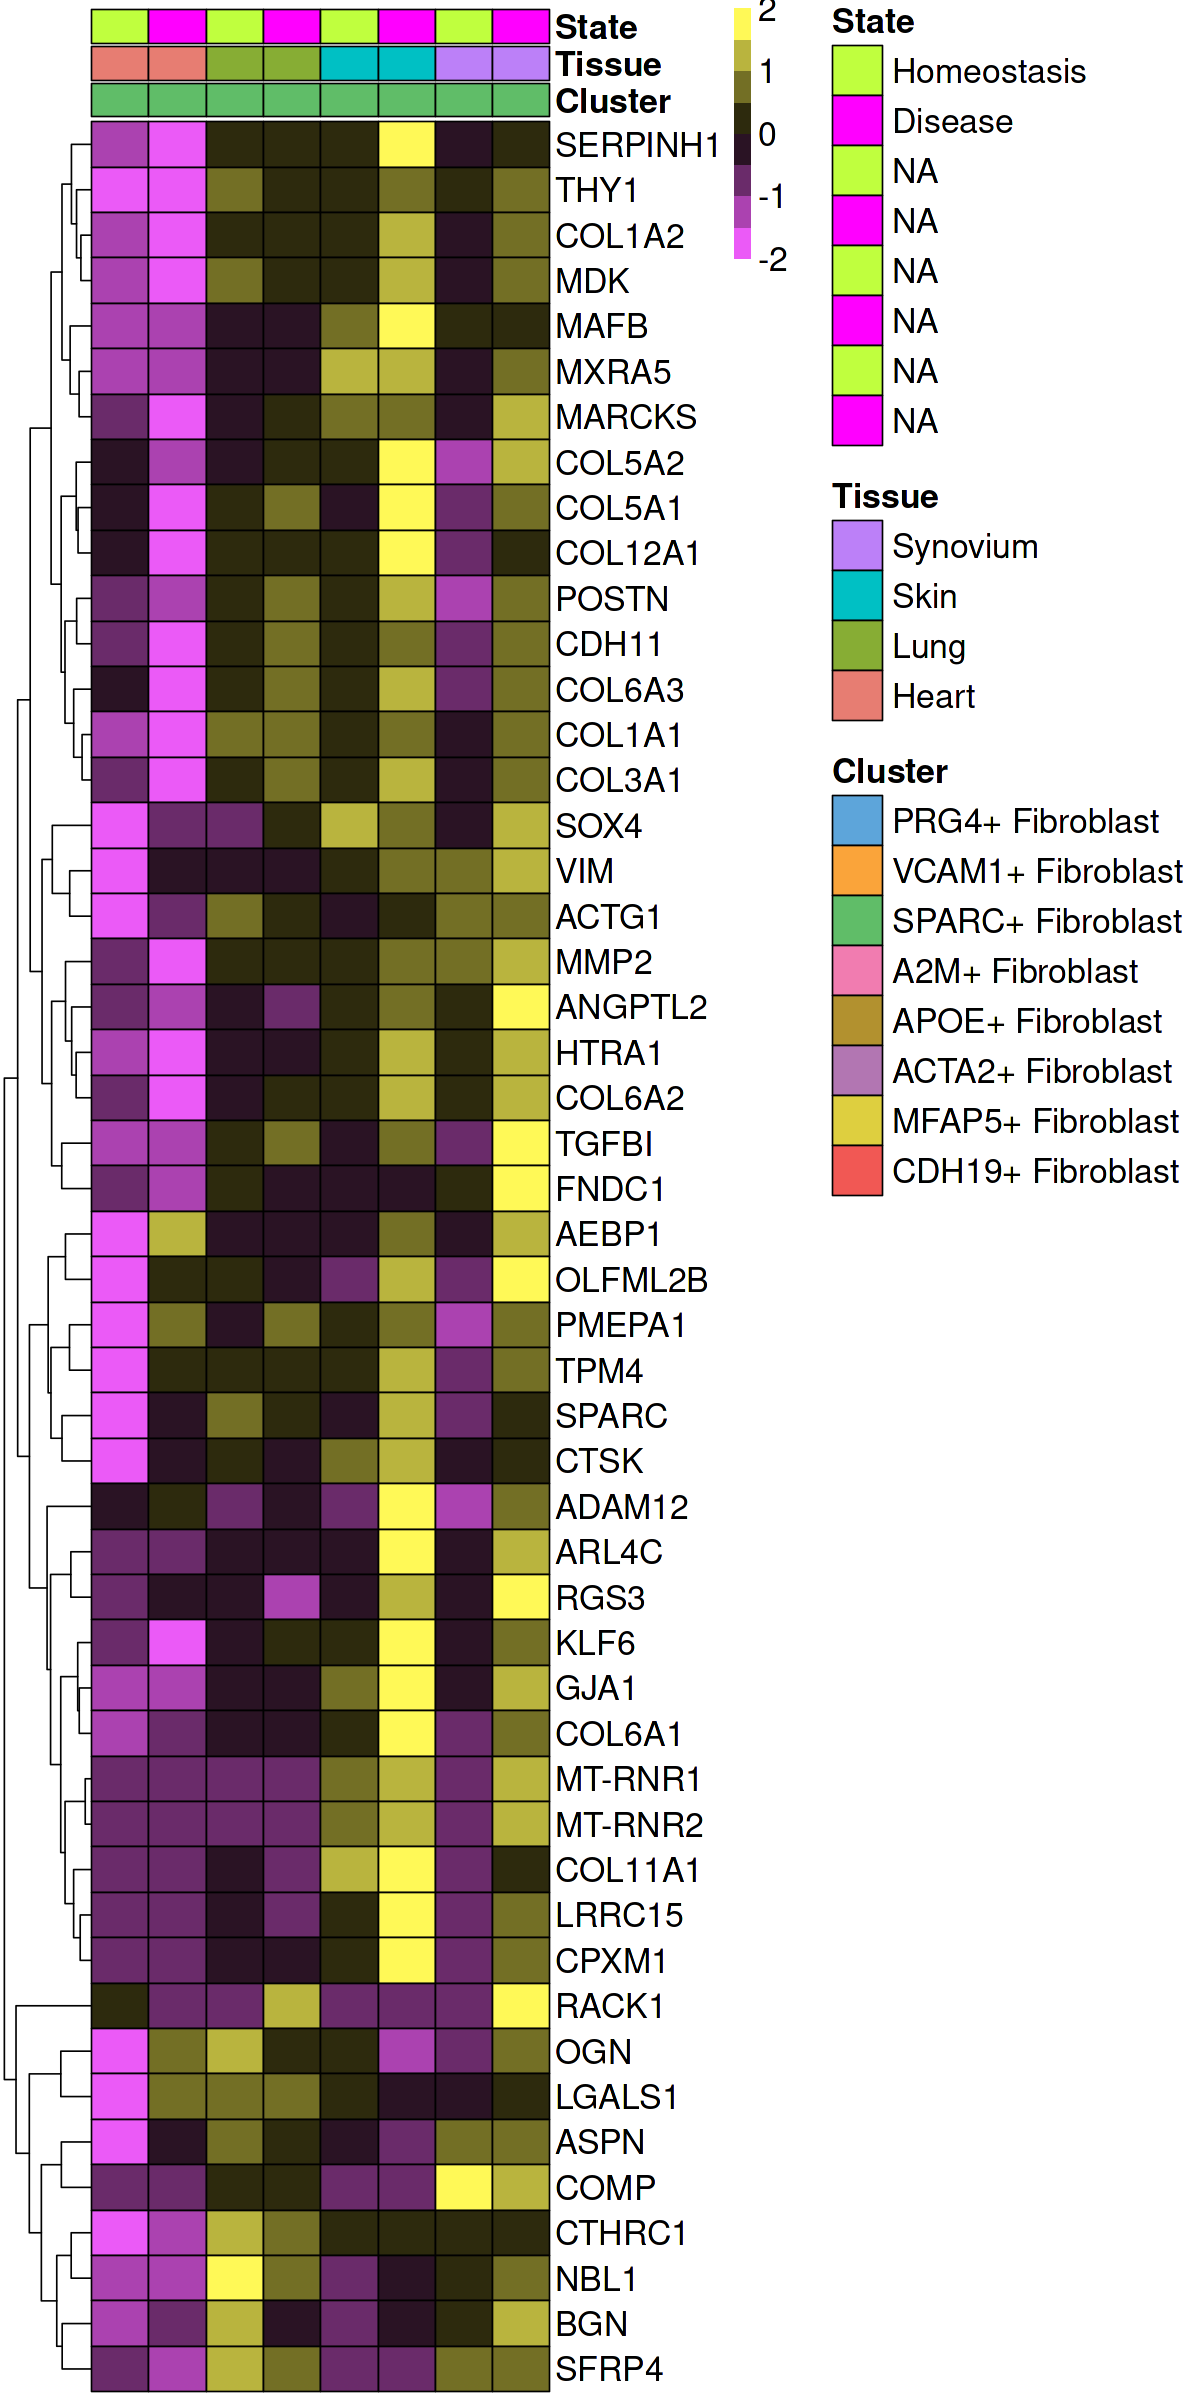

In [219]:
#Make your own
matrix <- GetAssayData(postnpos.avg, slot="data")
subset.matrix <- matrix[c(top50$gene), ]
data <- as.matrix(subset.matrix)
#Reposition the breaks at the quantiles of the data, then each color will represent an equal proportion of the data:
mat_breaks <- seq(min(data), max(data), length.out = 10)
quantile_breaks <- function(xs, n = 10) {
  breaks <- quantile(xs, probs = seq(0, 1, length.out = n))
  breaks[!duplicated(breaks)]
}
mat_breaks <- quantile_breaks(data, n = 11)

#Add metadata
postnpos.avg@meta.data$cluster <- "SPARC+ Fibroblast"
annotation_col <- as.data.frame(postnpos.avg@meta.data %>% select(cluster, tissue, state))

colnames(annotation_col) <- c("Cluster","Tissue","State")

#Create colour scheme
state.cols <- rep(c("olivedrab1","magenta1"),4)
names(state.cols) <- unique(postnpos.avg@meta.data$state)
metacols <- list(
  Cluster = fibro.cols,
  Tissue = tissue.cols,
  State = state.cols)

#Order cells by cluster
data <- data[,order(annotation_col$Tissue)]
#Scale data
scale_rows <- function(x) t(scale(t(x)))
data <- scale_rows(data) # Z-score
data[data > 2] <- 2
data[data < -2] <- -2

options(repr.plot.width=10, repr.plot.height=20)
#Generate heatmap
pheatmap(
  mat = data,
  border_color = "black",
  color = colorRampPalette(c("#EB5AF7","#0B0801","#FFF957"))(8),
  show_rownames = TRUE,
  show_colnames = FALSE,
  cluster_rows = TRUE,
  cluster_cols = FALSE,
  annotation_col = annotation_col,
  annotation_colors = metacols,
  fontsize = 20,
  fontsize_row = 20,
  scale = "none")